<a href="https://colab.research.google.com/github/mechvin96/ARAIP-Assigment/blob/main/AI_Recognition_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TSAHEYLU: Google Colab AI Recognition
This notebook processes your E-Puck robot's captures using the `Final_cifar10_model.h5` model.

### 1. Upload Requirements
Before running the cells, upload the following to the sidebar (Files icon):
1. Your model file: `Final_cifar10_model.h5`
2. Your robot's captures: All `.png` files from your capture folder.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# CIFAR-10 Class Labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Environment Ready. TensorFlow Version: {tf.__version__}")

Environment Ready. TensorFlow Version: 2.19.0


In [15]:
import os

# Define the Google Drive folder path
drive_folder_path = '/content/drive/Othercomputers/My Laptop/WebotCaptureImage'

# Load the H5 Model from the specified Google Drive path
model_path = os.path.join(drive_folder_path, 'Final_cifar10_model.h5')

if os.path.exists(model_path):
    # compile=False is used to bypass potential version mismatch errors in Keras metadata
    model = tf.keras.models.load_model(model_path, compile=False)
    print("SUCCESS: Model loaded and 'Brain' linked.")
else:
    print(f"ERROR: '{model_path}' not found. Please ensure the file is in the specified Google Drive folder and the path is correct.")

SUCCESS: Model loaded and 'Brain' linked.


Processing 4 images from '/content/drive/Othercomputers/My Laptop/WebotCaptureImage'

File: colab_ready_9952.png -> Predicted: BIRD (97.40%)
File: colab_ready_19353.png -> Predicted: CAT (81.46%)
File: colab_ready_13811.png -> Predicted: AIRPLANE (92.29%)
File: colab_ready_22764.png -> Predicted: AUTOMOBILE (99.91%)


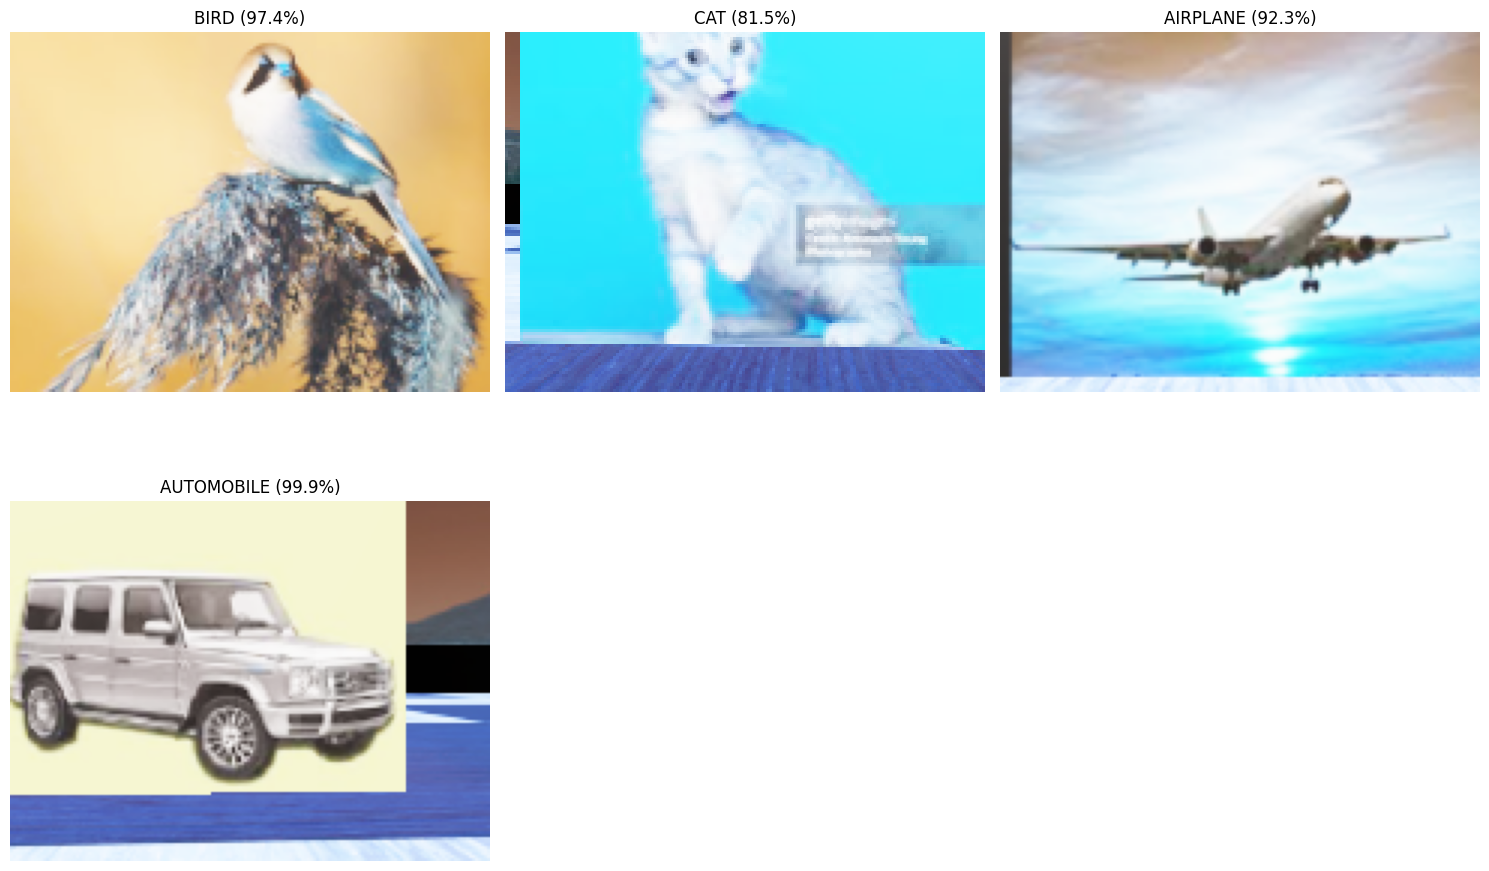

In [16]:
def process_and_predict(img_path):
    """Resizes image to 32x32 and runs inference."""
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((32, 32))
    img_array = np.array(img_resized).astype('float32') / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    # Perform prediction
    preds = model.predict(img_input, verbose=0)
    idx = np.argmax(preds)
    conf = np.max(preds)

    return class_names[idx], conf, img

# Define the Google Drive folder path (should be the same as in the model loading cell)
drive_folder_path = '/content/drive/Othercomputers/My Laptop/WebotCaptureImage'

# Find all PNG captures in the specified Google Drive folder
if not os.path.exists(drive_folder_path):
    print(f"ERROR: The specified Google Drive folder '{drive_folder_path}' does not exist. Please check the path.")
    images = []
else:
    images = [os.path.join(drive_folder_path, f) for f in os.listdir(drive_folder_path) if f.lower().endswith('.png')]

if not images:
    print(f"No .png images found in '{drive_folder_path}'. Please upload your Webots captures to this folder.")
else:
    print(f"Processing {len(images)} images from '{drive_folder_path}'\n")

    cols = 3
    rows = (len(images) // cols) + (1 if len(images) % cols != 0 else 0)
    plt.figure(figsize=(15, 5 * rows))

    for i, img_name in enumerate(images):
        label, confidence, original = process_and_predict(img_name)

        # Plot the result
        plt.subplot(rows, cols, i + 1)
        plt.imshow(original)
        plt.title(f"{label.upper()} ({confidence*100:.1f}%)")
        plt.axis('off')

        print(f"File: {os.path.basename(img_name)} -> Predicted: {label.upper()} ({confidence*100:.2f}%)")

    plt.tight_layout()
    plt.show()